#### outline
---
談論不同的注意力機制，共實作四種:
1. 簡化的注意力機制(Simplified Attention): 先說明注意力機制的概念  
單純看相量和向量之間像不像，來理解**加權平均**的概念
2. 自注意力(Self-Attention): 加入可訓練的權重  
讓模型自己學會**應該要更關注誰才可以完成任務**
3. 因果注意力(Causal Attention): 關注**先前和現在**的輸入內容
4. 多頭注意力(Multi-Head Attention): 自注意力和因果注意力延伸的注意力機制，可以使模型注意到來自不同表徵子空間的資訊  
簡而言之就是分頭行動，有人看語法、有人看代名詞，等等

In [1]:
import torch

#### math
---
核心的數學概念:  
先定義參數:  
1. Query(Q): 目前在看的token，想看這個token和同序列中其他token的關係  
2. Key(K):  序列中的每個token拿來與query比對的特徵  
K專門用來和Q做點積(Dot Product)比對用的  
3. Value(V): 當這個token被選中後(Key)，實際上要貢獻出的資訊特徵

Scaled Dot-Product Attention:  
**$Attention(Q, K, V)= softmax(\frac{QK^{T}}{\sqrt{d_{k}}}) \cdot V$**  
$\frac{1}{\sqrt{d_k}}$為縮放因子，防止點積結果過大導致Softmax梯度消失

### 3.3 利用自注意力機制，關注輸入序列中的不同位置
---
所謂的`self`是指model可以`自身`學習與評估輸入文本內容間每個token的關係和依賴程度，而機制的運作範圍侷限在`自身`的序列內部，所以可以注意到同一序列(同個句子)中的其他詞彙，並算出個別的注意力權重

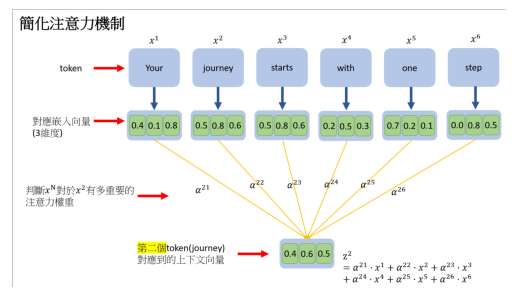

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img1 = mpimg.imread('figure1.png') 

plt.imshow(img1)
plt.axis('off') 
plt.show()

在自注意力中，透過**比較序列中每個元素間的資訊**，為序列中的每個元素($x^i$)**建立一個上下文向量($z^i$)**，所以**上下文向量是嵌入向量的升級版本**，裡面**包含了上下文關聯的資訊**  
引入一些專有動作，作為一個引路人:
1. `比較序列中每個元素間的資訊` $\rightarrow$ 點積($Query \cdot Key^T$)
2. `建立一個上下文向量(z^i)` $\rightarrow$ 加權求和 $z^i = \sum \alpha^{Ni} \cdot v^N $
3. `上下文向量是嵌入向量的升級版本` $\rightarrow$ 維度相同，代表同一個token
4. `包含了上下文關聯的資訊` $\rightarrow$ 最終目的

所以等會的實作環節會遵循以下三個步驟:
1. 比較資訊(Similarity):  
    $Score = \vec{Q} \cdot \vec{K}^T$
2. 決定權重(Normalization):  
    $\vec{\alpha} = Softmax(Score)$
3. 提取上下文(Context Aggregation):  
    $z = \sum(\vec{\alpha} \cdot \vec{v})$

##### 點積  
我不相信有任何人不知道點積的定義，所以下面只是show出拍透取的操作

In [3]:
vec_1 = torch.tensor([0.45, 0.12])
vec_2 = torch.tensor([0.64, 0.87])

res = 0.
for i, j in enumerate(vec_1):
    res += vec_1[i] * vec_2[i]

# 手動計算答案
print(res)

# pytorch函數計算(兩種方法)
print(torch.dot(vec_1, vec_2))
print(vec_1 @ vec_2)

tensor(0.3924)
tensor(0.3924)
tensor(0.3924)


#### 3.3.1 簡化得自注意力機制(不使用可訓練權重)

In [4]:
# 建立一個簡單序列
inputs = torch.tensor(
    [
        [0.43, 0.15, 0.89],     # Your      (x^1)
        [0.55, 0.87, 0.66],     # journey   (x^2)
        [0.57, 0.85, 0.64],     # starts    (x^3)
        [0.22, 0.58, 0.33],     # with      (x^4)
        [0.77, 0.25, 0.10],     # one       (x^5)
        [0.05, 0.80, 0.55]      # step      (x^6)
    ]
)

In [5]:
# step1. 用點積的方式算出Score

query = inputs[1]   # 查詢目標: 假設我們要看的是第二個token
attn_scores_2 = torch.empty(inputs.shape[0])
for i, x_i in enumerate(inputs):
    attn_scores_2[i] = torch.dot(x_i, query)    # 讓所有元素和第二個元素做內積(Q \cdot K^T)
print(attn_scores_2)
# 內積完是純數值

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


所以輸出內容中的每一個元素，皆為原本序列中每個元素和第二個元素內積後的結果  
為什麼第二項不是1呀? 因為還沒normalized，長度不是1。

In [6]:
# step2. 將score做歸一化(v1. 用最簡單的*比例*)
attn_weights_2_tmp = attn_scores_2 / attn_scores_2.sum()
print("Attention weight:", attn_weights_2_tmp)
print("Sum:", attn_weights_2_tmp.sum())

Attention weight: tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
Sum: tensor(1.0000)


有弊端，如果內積後為負數，負數的權重先不要吧

In [7]:
# step2. 將score做歸一化(v2. 用softmax)
attn_weights_2 = torch.softmax(attn_scores_2, dim=0)
print("Attention weights:", attn_weights_2)
print("Sum:", attn_weights_2.sum())

Attention weights: tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
Sum: tensor(1.)


還記得我們先前在[pytorch.ipynb](https://github.com/aqingo3o/1004-LLM/blob/d48c38ab1f22a76e9b0c0b5c6f9e5c2af53677cf/exp/RF/pytorch.ipynb)學到的使用`softmax`激活函數把原始分數壓成機率嗎?  
這邊做了一樣的事情，將score用softmax壓一壓，確保我們輸出的權重值永遠介在`0-1`之間

In [8]:
# step3. 計算最後的上下文向量
query = inputs[1]   # 一樣，我們只看第二個token
context_vec_2 = torch.zeros(query.shape)     # 建立一個空向量等等放數字進去
for i, x_i in enumerate(inputs):
    context_vec_2 += attn_weights_2[i] * x_i # 計算上下文向量(所有輸入向量的加權和) 
print(context_vec_2)

tensor([0.4419, 0.6515, 0.5683])


#### 3.3.2 計算所有輸入token的注意力權重
剛剛都只有關注第二個token，看他和別人的點積，進而壓成權重，最後變成上下文向量；現在要將序列中的每個token做一樣的事情

In [9]:
# step1. 算score
attn_scores = inputs @ inputs.T 
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


剛剛提到算score就是算點積，對於矩陣來說就是自己乘上自己的轉置(見fig.2)

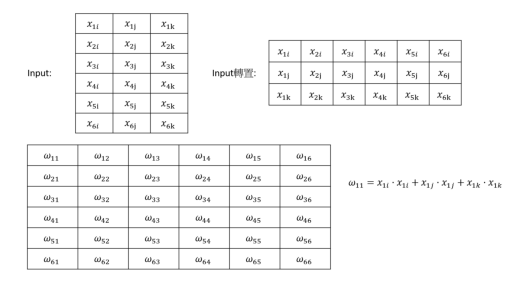

In [10]:
img2 = mpimg.imread('figure2.png') 

plt.imshow(img2)
plt.axis('off') 
plt.show()

In [11]:
# step2. normalized
attn_weights = torch.softmax(attn_scores, dim=-1)
print(attn_weights)
print("All row sums:", attn_weights.sum(dim=-1))    # 將每一列總和確認都是1

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])
All row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])


一樣使用softmax將權重壓成在0-1之間的數字，dim=-1代表橫向加總要為1

In [12]:
# step3. context aggregation
all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


用fig.3建立圖像概念

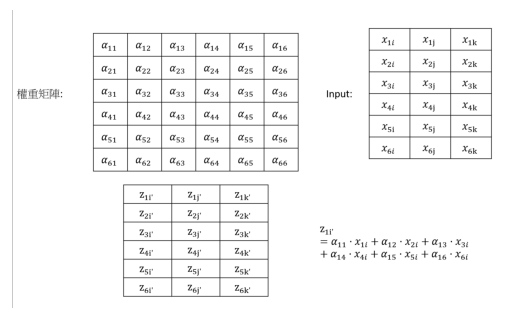

In [13]:
img = mpimg.imread('figure3.png') 

plt.imshow(img)
plt.axis("off")
plt.show()

### 3.4 使用`可訓練權重`實作自注意力機制
---
實作完整的自注意力機制，和上面大差不差，主要在於引入了**可以隨著model訓練的過程更新的`權重矩陣`($W_q$、$W_k$、$W_v$)**，這部分才確確實實的從原始輸入**X**中投影出獨立的**Q(Query)、K(Key)、V(Value)**三個向量:  
1. $\vec{Q} = \vec{X} \cdot \vec{W}_q$
2. $\vec{K} = \vec{X} \cdot \vec{W}_k$
3. $\vec{V} = \vec{X} \cdot \vec{W}_v$

再丟進`Scaled Dot-Product Attention`公式計算

#### 3.4.1 逐步計算注意力權重

In [14]:
x_2 = inputs[1]
print(x_2)              # 先確認和先前自訂的嵌入向量相同

tensor([0.5500, 0.8700, 0.6600])


In [15]:
d_in = inputs.shape[1]  # rows，應該要和inputs的columns一樣才能符合矩陣乘法
d_out = 2               # 內積後，Q、K、V輸出的維度(columns)

torch.manual_seed(123)  # 方便和之後要做的東西比較，先設定種子碼
# 用.randn(常態分佈)讓值有正有負
# requires_grad=True，把需要梯度打開，之後訓練才會更新
W_query = torch.nn.Parameter(torch.randn(d_in, d_out), requires_grad=True)
W_key = torch.nn.Parameter(torch.randn(d_in, d_out), requires_grad=True)
W_value = torch.nn.Parameter(torch.randn(d_in, d_out), requires_grad=True)

# 輸出看看，確認是3*2矩陣
print(W_query)
print(W_key)
print(W_value)

Parameter containing:
tensor([[-0.1115,  0.1204],
        [-0.3696, -0.2404],
        [-1.1969,  0.2093]], requires_grad=True)
Parameter containing:
tensor([[-0.9724, -0.7550],
        [ 0.3239, -0.1085],
        [ 0.2103, -0.3908]], requires_grad=True)
Parameter containing:
tensor([[ 0.2350,  0.6653],
        [ 0.3528,  0.9728],
        [-0.0386, -0.8861]], requires_grad=True)


In [16]:
# 一樣先看x_2，算出第2個token的query、key、value
query_2 = x_2 @ W_query
key_2 = x_2 @ W_key
value_2 = x_2 @ W_value

print(query_2)
print(key_2)
print(value_2)

tensor([-1.1729, -0.0048], grad_fn=<SqueezeBackward4>)
tensor([-0.1142, -0.7676], grad_fn=<SqueezeBackward4>)
tensor([0.4107, 0.6274], grad_fn=<SqueezeBackward4>)


所以在這邊，第二個token(journey)就被分成三種向量了，分別為query、key、value，對於理解這三個`術語`，G學長有個很厲害的解釋:  
假設現在在**相親**，現在token是`紅魚`($X_1$)，原始的嵌入向量包含了我所有的特徵[身高, 職業, 喜好, 喜歡吃甚麼...]，現在在做的事就是把我這個人拆成三個不同的檔案:  
檔案(1) **Query**($Q_1 = X_1 \cdot W_q$): 我要找甚麼?  
也就是我的擇偶條件，$W_q$的作用即為將$X$裡面的需求特徵提取出來  
e.g. 我在找很會跳舞的人(但我自己可以不會跳舞)  
檔案(2) **Key**($K_1 = X_1 \cdot W_k$): 我是怎樣的人?  
aka我的個人檔案&標籤，$W_k$的作用是把$X$裡面的屬性特徵提取出來  
e.g. 我是會打毛線的人  
檔案(3) **Value**($V_1 = X_1 \cdot W_v$): 配對到後，可以貢獻甚麼?  
這是我具體可以做到的事情  
e.g. 我可以給你一個毛線紅魚

假設現在有另一個token是`藍魚`($X_2$)，他剛好**Query(理想型)($Q_2$)**是**喜歡會打毛線的人**，而紅魚的**Key(條件)($K_1$)**說明我會打毛線，所以點積($Q_2 \cdot K_1$)分數就會很高，結果($V_1$)就是藍魚關注到紅魚，並從我這邊拿到一個毛線紅魚

如果不這麼分，純粹以3.3的方法做點積的話，紅魚只會和和自己極度相似的紅魚2號點積分數很高，但根本不是自己的理想型

現在把比喻拿掉來試圖搞懂他的定義，所以這邊做的事就是將輸入的嵌入向量(X)投影到不同的特徵子空間(Feature Subspaces)內  
1. Query($Q = X \cdot W_q$): 搜尋向量  
    - 定義: 將x投影到「查詢子空間」後的向量
    - 功能: 當下關注的這個token在尋找什麼樣的特徵
2. Key($K = X \cdot W_k$): 索引向量  
    - 定義: 將x投影到「索引子空間」後的向量
    - 功能: 當下關注的這個token有哪些特徵或標籤讓其他token檢索
3. Value($V = X \cdot W_v$): 內容向量  
    - 定義: 將x投影到「內容子空間」後的向量
    - 功能: 實際攜帶語意資訊的載體

In [17]:
# 雖然現在只關注第二個token，但還是要算出所有token的keys和values以做計算
keys = inputs @ W_key
values = inputs @ W_value
# 印出確認是[6個token, 每個token共2維度的向量]
print("keys.shape:", keys.shape)
print("values.shape:", values.shape)
print(keys)
print(values)

keys.shape: torch.Size([6, 2])
values.shape: torch.Size([6, 2])
tensor([[-0.1823, -0.6888],
        [-0.1142, -0.7676],
        [-0.1443, -0.7728],
        [ 0.0434, -0.3580],
        [-0.6467, -0.6476],
        [ 0.3262, -0.3395]], grad_fn=<MmBackward0>)
tensor([[ 0.1196, -0.3566],
        [ 0.4107,  0.6274],
        [ 0.4091,  0.6390],
        [ 0.2436,  0.4182],
        [ 0.2653,  0.6668],
        [ 0.2728,  0.3242]], grad_fn=<MmBackward0>)


In [18]:
# 還記得step1. 嗎? 用點積算出scores(Q \cdot K^T)
# 一樣先focus on token 2
attn_scores_2 = query_2 @ keys.T
print(attn_scores_2)

tensor([ 0.2172,  0.1376,  0.1730, -0.0491,  0.7616, -0.3809],
       grad_fn=<SqueezeBackward4>)


所以這邊印出[6]的矩陣，就是token 2的查詢向量和其他token的索引向量的分數(內積後的值)

In [19]:
# step2. normalization, 將注意力分數轉成注意力權重
d_k = keys.shape[-1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)
print(attn_weights_2)
print(attn_weights_2.sum())

tensor([0.1704, 0.1611, 0.1652, 0.1412, 0.2505, 0.1117],
       grad_fn=<SoftmaxBackward0>)
tensor(1.0000, grad_fn=<SumBackward0>)


recall: $Attention(Q, K, V)= softmax(\frac{QK^{T}}{\sqrt{d_{k}}}) \cdot V$  
現在在做前半段的部分$softmax(\frac{QK^{T}}{\sqrt{d_{k}}})$；$Q \cdot K^T$也就是我們剛剛算完的`attn_scores_2`

In [20]:
# step3. 提取上下文(\sum(\alpha \cdot v))
# 一樣foucs on token 2，算出它的上下文向量
# attn_weights_2 -> [6]; value -> [6, 2] ----> 相乘得到[2]
context_vec_2 = attn_weights_2 @ values
print(context_vec_2)

tensor([0.2854, 0.4081], grad_fn=<SqueezeBackward4>)


剛剛已經打包好$softmax(\frac{QK^{T}}{\sqrt{d_{k}}})$為`attn_weight_2`了，現在只要在乘上`v`即可計算出上下文向量  
所以第二個token `journey`升等了，從原本孤單冷漠的`journey`變成社會化過的`journey`，向量本身包含了對於其他token的語意

所以模型在解讀文本的時候就會重複這個機制去調整原始token的嵌入向量變成上下文向量，每次看到不同文本的相同token雖然遷入向量一樣、但上下文向量是會改變的

#### 3.4.2

In [21]:
# 剛剛只focus on token 2，現在把它推廣到所有token，打包成一個類別(class)
import torch.nn as nn
class SelfAttention_v1(nn.Module):
    # 初始化每個參數
    def __init__(self, d_in, d_out):
        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Parameter(torch.randn(d_in, d_out))
        self.W_key = nn.Parameter(torch.randn(d_in, d_out))
        self.W_value = nn.Parameter(torch.randn(d_in, d_out))

    # 剛剛每個步驟(pipeline)
    def forward(self, x):
        # 每個token投影到不同特徵子空間
        # ---------------------------- #
        keys = x @ self.W_key
        queries = x @ self.W_query
        values = x @ self.W_value
        # ---------------------------- #

        # step1. 點積算分數
        attn_scores = queries @ keys.T
        # 現在都是2維張量，所以直接轉置沒關係，但還記得上一章dataloader分配好一口的量嗎? 顯然不只一個序列
        # 所以會變成3維張量[batch, seq_len, d_out]，只要轉最後兩維就好，第一維不用管，所以改變程式碼為下面那條
        # attn_scores = queries @ keys.transpose(-2, -1)
        # step2. normalization
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        # step 3. 提取上下文
        context_vec = attn_weights @ values
        return context_vec

In [22]:
# 把inputs餵給他
torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)
print(sa_v1(inputs))

# 可以發現這邊的第二行和上面focus on token 2的ans.一樣

tensor([[0.2845, 0.4071],
        [0.2854, 0.4081],
        [0.2854, 0.4075],
        [0.2864, 0.3974],
        [0.2863, 0.3910],
        [0.2860, 0.4039]], grad_fn=<MmBackward0>)


In [23]:
# v2: 升級版本，不再用nn.Parameter自定義權重；而是使用nn.Linear，他的初始化權重的方式更加複雜而穩定
class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        # ---------------------------- #
        # 定義三個投影矩陣: W_q, W_k, W_v
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        # ---------------------------- #
        
    def forward(self, x):
        #　將每個inputs投影到不同的特徵子空間
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        
        # step1. 算分數
        #attn_scores = queries @ keys.T
        attn_scores = queries @ keys.transpose(-2, -1)

        # step2. 歸一化
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        
        # step3. 提取上下文
        context_vec = attn_weights @ values
        return context_vec

In [24]:
# v2: 升級版本，不再用nn.Parameter自定義權重；而是使用nn.Linear，他的初始化權重的方式更加複雜而穩定
class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        # ---------------------------- #
        # 定義三個投影矩陣: W_q, W_k, W_v
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        # ---------------------------- #
        
    def forward(self, x):
        #　將每個inputs投影到不同的特徵子空間
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        
        # step1. 算分數
        #attn_scores = queries @ keys.T
        attn_scores = queries @ keys.transpose(-2, -1)

        # step2. 歸一化
        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1]**0.5, dim=-1
        )
        
        # step3. 提取上下文
        context_vec = attn_weights @ values
        return context_vec

In [25]:
d_in = inputs.shape[1]  # 和inputs的columns數一樣才能符合矩陣乘法
d_out = 2               # 內積後，Q、K、V輸出的維度

torch.manual_seed(123)
sa_v2 = SelfAttention_v2(d_in, d_out)
print(sa_v2(inputs))

tensor([[-0.5337, -0.1051],
        [-0.5323, -0.1080],
        [-0.5323, -0.1079],
        [-0.5297, -0.1076],
        [-0.5311, -0.1066],
        [-0.5299, -0.1081]], grad_fn=<MmBackward0>)


結果顯而易見的，儘管種子碼相同，最後每個token的上下文向量都和v1時輸出的不同，也佐證初始化權重的方式不同

### 3.5 使用因果注意力遮蔽未來的字詞
---
這邊實作`因果注意力`確保在生成序列的時候model只會考慮過去和現在的輸入，不會考慮到未來的資料；所以與3.4那種`標準`的自注意力機制的差別在於，因果注意力只會計算當前或過去的token的注意力分數，舉例來說，先前的標準自注意力機制我們focus在token 2，但在計算scores時也會看token 3-6對於他的分數；但現在會利用遮罩來避免這件事發生  
為什麼要這麼做?? 因為在訓練GPT這類生成式模型時，目標是要模型**預測**下一個詞

#### 3.5.1 應用因果注意力遮罩  
先把注意力權重畫出來(fig.4)，因為不能考慮**未來**，所以在這個矩陣就是把對角線上面的注意力權重遮蔽(歸零)   
步驟如下:  
1. 注意力分數  
    $\downarrow$使用$Softmax$函式
2. 注意力權重  
    $\downarrow$使用遮罩將對角線上方的數值歸零
3. 有遮罩的注意力分數  
    $\downarrow$一樣每列進行歸一化
4. 有遮罩的注意力權重

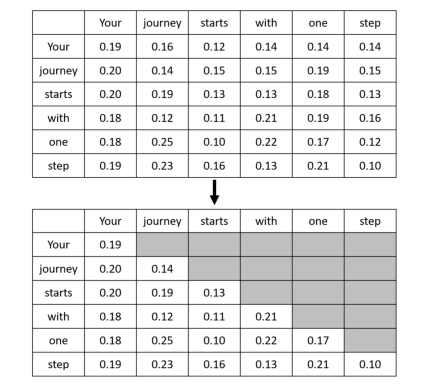

In [26]:
img4 = mpimg.imread('figure4.png') 

plt.imshow(img4)
plt.axis('off') 
plt.show()

In [27]:
# 單純建立原始、無任何遮罩的注意力權重
queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs)
attn_scores = queries @ keys.T
attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=1)
print(attn_weights)

tensor([[0.1717, 0.1762, 0.1761, 0.1555, 0.1627, 0.1579],
        [0.1636, 0.1749, 0.1746, 0.1612, 0.1605, 0.1652],
        [0.1637, 0.1749, 0.1746, 0.1611, 0.1606, 0.1651],
        [0.1636, 0.1704, 0.1702, 0.1652, 0.1632, 0.1674],
        [0.1667, 0.1722, 0.1721, 0.1618, 0.1633, 0.1639],
        [0.1624, 0.1709, 0.1706, 0.1654, 0.1625, 0.1682]],
       grad_fn=<SoftmaxBackward0>)


In [28]:
# 利用.tril建立一個乾淨的遮罩，對角線上方為零、其餘為1
context_length = attn_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [29]:
# 將原始的注意力權重矩陣和遮罩相乘，即可讓對角線以上歸零，留下過去與當下的注意力權重
masked_simple = attn_weights * mask_simple
print(masked_simple)
# 但有個問題喔，行總和不為1

tensor([[0.1717, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1636, 0.1749, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1637, 0.1749, 0.1746, 0.0000, 0.0000, 0.0000],
        [0.1636, 0.1704, 0.1702, 0.1652, 0.0000, 0.0000],
        [0.1667, 0.1722, 0.1721, 0.1618, 0.1633, 0.0000],
        [0.1624, 0.1709, 0.1706, 0.1654, 0.1625, 0.1682]],
       grad_fn=<MulBackward0>)


In [30]:
row_sums = masked_simple.sum(dim=1, keepdim=True)
# 透過比例的方式進行歸一化
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4833, 0.5167, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3190, 0.3408, 0.3402, 0.0000, 0.0000, 0.0000],
        [0.2445, 0.2545, 0.2542, 0.2468, 0.0000, 0.0000],
        [0.1994, 0.2060, 0.2058, 0.1935, 0.1953, 0.0000],
        [0.1624, 0.1709, 0.1706, 0.1654, 0.1625, 0.1682]],
       grad_fn=<DivBackward0>)


但你會發現上面這個方式有夠多餘且效率低，下面有法二，並且是更通用的做法  
步驟如下:  
1. 注意力分數  
    $\downarrow$用$-\infty$遮蔽對角線以上的元素
2. 注意力權重  
    $\downarrow$應用$Softmax$函式
3. 有遮罩的注意力權重

In [31]:
# step1. 用-\infty遮住對角線以上的元素
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)   #.triu -> 取上三角形; diagonal -> 主對角線往後一格填入1(要看到自己)
print(mask)
# print(attn_scores)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)   # 用.bool()把0轉成False, 1轉成True，而後將True的地方填入-\infty
print(masked)

tensor([[0., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0.]])
tensor([[0.3111,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.1655, 0.2602,   -inf,   -inf,   -inf,   -inf],
        [0.1667, 0.2602, 0.2577,   -inf,   -inf,   -inf],
        [0.0510, 0.1080, 0.1064, 0.0643,   -inf,   -inf],
        [0.1415, 0.1875, 0.1863, 0.0987, 0.1121,   -inf],
        [0.0476, 0.1192, 0.1171, 0.0731, 0.0477, 0.0966]],
       grad_fn=<MaskedFillBackward0>)


In [32]:
# 應用softmax函式
attn_weights = torch.softmax(masked / keys.shape[-1]**0.5, dim=1)
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4833, 0.5167, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3190, 0.3408, 0.3402, 0.0000, 0.0000, 0.0000],
        [0.2445, 0.2545, 0.2542, 0.2468, 0.0000, 0.0000],
        [0.1994, 0.2060, 0.2058, 0.1935, 0.1953, 0.0000],
        [0.1624, 0.1709, 0.1706, 0.1654, 0.1625, 0.1682]],
       grad_fn=<SoftmaxBackward0>)


recall: softmax函式 $\rightarrow \frac{e^{x}}{\sum e^{x}}$，所以當輸入是$-\infty$時: $e^{-\infty} \approx 0$，所以也不會影響到其他同row的元素  
結果：被遮蔽的token直接退出，由剩下的token重新瓜分100%的權重

#### 3.5.2 用dropout遮蔽額外的注意力權重

在注意力權重的大矩陣裡面，**隨機遮罩**某幾個注意力權重，目的是為了不要讓model死記硬背，必須學會看懂上下文判斷答案  
所以這邊利用**dropout**防止**過擬合**  
因為是學習的過程，所以只在訓練時打開

In [33]:
torch.manual_seed(123)
# 設定遮罩，要遮住50%的元素
dropout = torch.nn.Dropout(0.5)
# 這裡只是示範，所以建立一個6*6的矩陣，裡面元素都是1
example = torch.ones(6, 6)
#print(example)
print(dropout(example))

tensor([[2., 2., 2., 2., 2., 2.],
        [0., 2., 0., 0., 0., 0.],
        [0., 0., 2., 0., 2., 0.],
        [2., 2., 0., 0., 0., 2.],
        [2., 0., 0., 0., 0., 2.],
        [0., 2., 0., 0., 0., 0.]])


因為可以傳遞下去的東西少了一半，為了使輸出的期望值不變，因此會將剩下的元素放大(除以1-p)，保持訊號量級不變

In [34]:
torch.manual_seed(123)
# 實際應用在我們已經做好對角以上為0的注意力權重
print(dropout(attn_weights))

tensor([[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 1.0335, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.6804, 0.0000, 0.0000, 0.0000],
        [0.4889, 0.5090, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3988, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0000, 0.3418, 0.0000, 0.0000, 0.0000, 0.0000]],
       grad_fn=<MulBackward0>)


不是阿幹，如果mask到本身就0的地方，而其他訊號放大，會加強差異吧  
你答對了，就是要這個效果，有時候權重被放大、有時候甚至為0，簡單來說加強訓練難度，之後在面對測試資料的時候才可以更穩定的判斷上下文關係

#### 3.5.3 實作一個精簡的因果注意力機制

In [35]:
# 還記得dataloader幫我們分好一口要吃多少序列了嗎? 所以這邊引入batch維度再將問題複雜化一些些、但也更貼近真實情況
batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape)

torch.Size([2, 6, 3])


印出的數字代表: 一口吃兩個序列、每個序列有6個token、每個token的嵌入向量有3維

In [36]:
class CausalAttention(nn.Module):
    def __init__(self, d_in,d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        # 投影到不同特徵子空間
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        # ------------------------------------------------- #

        # 準備dropout的工具
        self.dropout = nn.Dropout(dropout)

        # 預先製作一個巨大的上三角遮罩(上三角全為1，其餘為0)
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )
        # ------------------------------------------------- #

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        # 變數為自己投影到特徵子空間後的向量
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)
        # ------------------------------------------------- #

        # step1. 算出attention scores
        attn_scores = queries @ keys.transpose(1, 2)
        # ------------------------------------------------- #

        # step2. 因果遮罩給他蓋下去
        attn_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf
        )
        # ------------------------------------------------- #

        # step3. 用softmax歸一化
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        # ------------------------------------------------- #

        # step4. 用dropout隨機遮住不同注意力權重
        attn_weights = self.dropout(attn_weights)
        # ------------------------------------------------- #

        # step5. 擷取上下文
        context_vec = attn_weights @ values
        return context_vec
        # ------------------------------------------------- #

In [37]:
torch.manual_seed(123)
context_length = batch.shape[1]
ca = CausalAttention(d_in, d_out, context_length, 0.0)
context_vecs = ca(batch)
print("context_vecs.shape:", context_vecs.shape)

context_vecs.shape: torch.Size([2, 6, 2])


### 3.6 單頭擴充至多頭注意力
---
所謂`多頭`是指將注意力分成多頭行動，增加效率

#### 3.6.1 利用`堆疊`多個單頭注意力的方式實作

In [ ]:
class MultiHeadAttentionWrapper(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        # 要多少頭就做幾次製造Q、K、V向量的步驟
        self.heads = nn.ModuleList(
            [CausalAttention(d_in, d_out, context_length, dropout, qkv_bias)
             for _ in range(num_heads)]
        )

    def forward(self, x):
        return torch.cat([head(x) for head in self.heads], dim=-1)
    # torch.cat就是把不同頭做出來的上下文向量黏在一起，dim=-1就是接在最後一個維度後面

雖然用同樣的數據訓練，但因為初始狀態是隨機的，且模型有「多樣化」的需求，所以$W_{q1}$、$W_{q2}$、...、$W_{qN}$會自動分配工作(e.g.有人找「主詞」、有人找「情感」等等)，不會導致最後$W_{q1}$和$W_{q2}$長很像的問題；換句話說。每個頭都在不同的子空間、不同的視角去觀察數據

In [45]:
torch.manual_seed(123)
context_length = batch.shape[1]
d_in, d_out = 3, 2
mha = MultiHeadAttentionWrapper(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)

print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)
context_vecs.shape: torch.Size([2, 6, 4])


note:  
1. 還記得我們前面有定義`batch = torch.stack((inputs, inputs), dim=0)`嗎？所以我們batch=2所吃的那兩口資料是一樣的(都是`inputs`)，而batch中每筆參數都是平行處理的，因此我們會得到一樣的結果
2. 上下文向量變成4維度了，因為第一組 **$W_{q1}$**、**$W_{k1}$**、**$W_{v1}$** 和第二組 **$W_{q2}$**、**$W_{k2}$**、**$W_{v2}$** 所生成的上下文向量被接在一起了；不過為什麼要這樣呢? 不能透過相加或相乘的方式結合每個頭的*研究發現*嗎?  
    不行。  
    因為第一個頭和第二個頭關注的是不同的特徵，所以將其獨立才能夠更好對應索求特徵；以健康檢查報告為例，如果對身體每個部位進行經過標準化的健康評分時，0即為健康，無論$+-$值皆為異常，現在每個head為不同部位打分，假設目前的token `黃魚` 缺牙且遠視，第一個頭看到他缺牙，給他$-5$分，第二個頭看到他遠視，給他$+5$分，所以健康報告會看到:  
    牙齒: $-5$  
    視力: $+5$  
    用上下文向量的語言就是: $[-5,\ +5]$  
    但如果變成相加，會發生`破壞性干涉`，$-5+5=0$，健康評估直接變非常健康的人，因此才需要用**黏在後面**的方式處理不同head產出的上下文向量

#### 3.6.2 實作具有權重切分的多頭注意力

In [40]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length), diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys    = self.W_key(x)
        queries = self.W_query(x)
        values  = self.W_value(x)

        keys    = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values  = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        keys    = keys.transpose(1, 2)
        values  = values.transpose(1, 2)
        queries = queries.transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)
        mask_bool   = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool, -torch.inf)
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)
        context_vec = (attn_weights @ values).transpose(1, 2)
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)
        return context_vec

In [41]:
a = torch.tensor([[[[0.2745, 0.6584, 0.2775, 0.8573],
                    [0.8993, 0.0390, 0.9268, 0.7388], 
                    [0.7179, 0.7058, 0.9156, 0.4340]], 
                    
                    [[0.0772, 0.3565, 0.1479, 0.5331], 
                     [0.4066, 0.2318, 0.4545, 0.9737], 
                     [0.4606, 0.5159, 0.4220, 0.5786]]]])
print(a @ a.transpose(2, 3))

tensor([[[[1.3208, 1.1631, 1.2879],
          [1.1631, 2.2150, 1.8424],
          [1.2879, 1.8424, 2.0402]],

         [[0.4391, 0.7003, 0.5903],
          [0.7003, 1.3737, 1.0620],
          [0.5903, 1.0620, 0.9912]]]])


In [42]:
first_head = a[0, 0, :, :]
first_res = first_head @ first_head.T
print("First head:\n", first_res)

second_head = a[0, 1, :, :]
second_res = second_head @ second_head.T
print("\nSecond head:\n", second_res)

First head:
 tensor([[1.3208, 1.1631, 1.2879],
        [1.1631, 2.2150, 1.8424],
        [1.2879, 1.8424, 2.0402]])

Second head:
 tensor([[0.4391, 0.7003, 0.5903],
        [0.7003, 1.3737, 1.0620],
        [0.5903, 1.0620, 0.9912]])


In [43]:
torch.manual_seed(123)
batch_size, context_length, d_in = batch.shape
d_out = 2
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)
print(context_vecs)
print("context_vecs.shape:", context_vecs.shape)

tensor([[[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]],

        [[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]]], grad_fn=<ViewBackward0>)
context_vecs.shape: torch.Size([2, 6, 2])
